**Table of contents**<a id='toc0_'></a>    
- [Multiple fluorophores, ET enabled, effects of irradiance](#toc1_)    
  - [Reading the data](#toc1_1_)    
  - [Figure](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Multiple fluorophores, ET enabled, effects of irradiance](#toc0_)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams

import fluopy.emissions as em
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2

reading_from_1 = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_11_multi_f_et_irradiance\OET"
reading_from_2 = r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_11_multi_f_et_irradiance\noOET"
saving_to = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_11_multi_f_et_irradiance"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## <a id='toc1_1_'></a>[Reading the data](#toc0_)

In [3]:
df100_OET = pd.read_parquet(reading_from_1 + r"\irradiance100\emission_df.parquet")
df50_OET = pd.read_parquet(reading_from_1 + r"\irradiance50\emission_df.parquet")
df25_OET = pd.read_parquet(reading_from_1 + r"\irradiance25\emission_df.parquet")
df10_OET = pd.read_parquet(reading_from_1 + r"\irradiance10\emission_df.parquet")
df1_OET = pd.read_parquet(reading_from_1 + r"\irradiance1\emission_df.parquet")

df100_noOET = pd.read_parquet(reading_from_2 + r"\irradiance100\emission_df.parquet")
df50_noOET = pd.read_parquet(reading_from_2 + r"\irradiance50\emission_df.parquet")
df25_noOET = pd.read_parquet(reading_from_2 + r"\irradiance25\emission_df.parquet")
df10_noOET = pd.read_parquet(reading_from_2 + r"\irradiance10\emission_df.parquet")
df1_noOET = pd.read_parquet(reading_from_2 + r"\irradiance1\emission_df.parquet")

## <a id='toc1_2_'></a>[Figure](#toc0_)

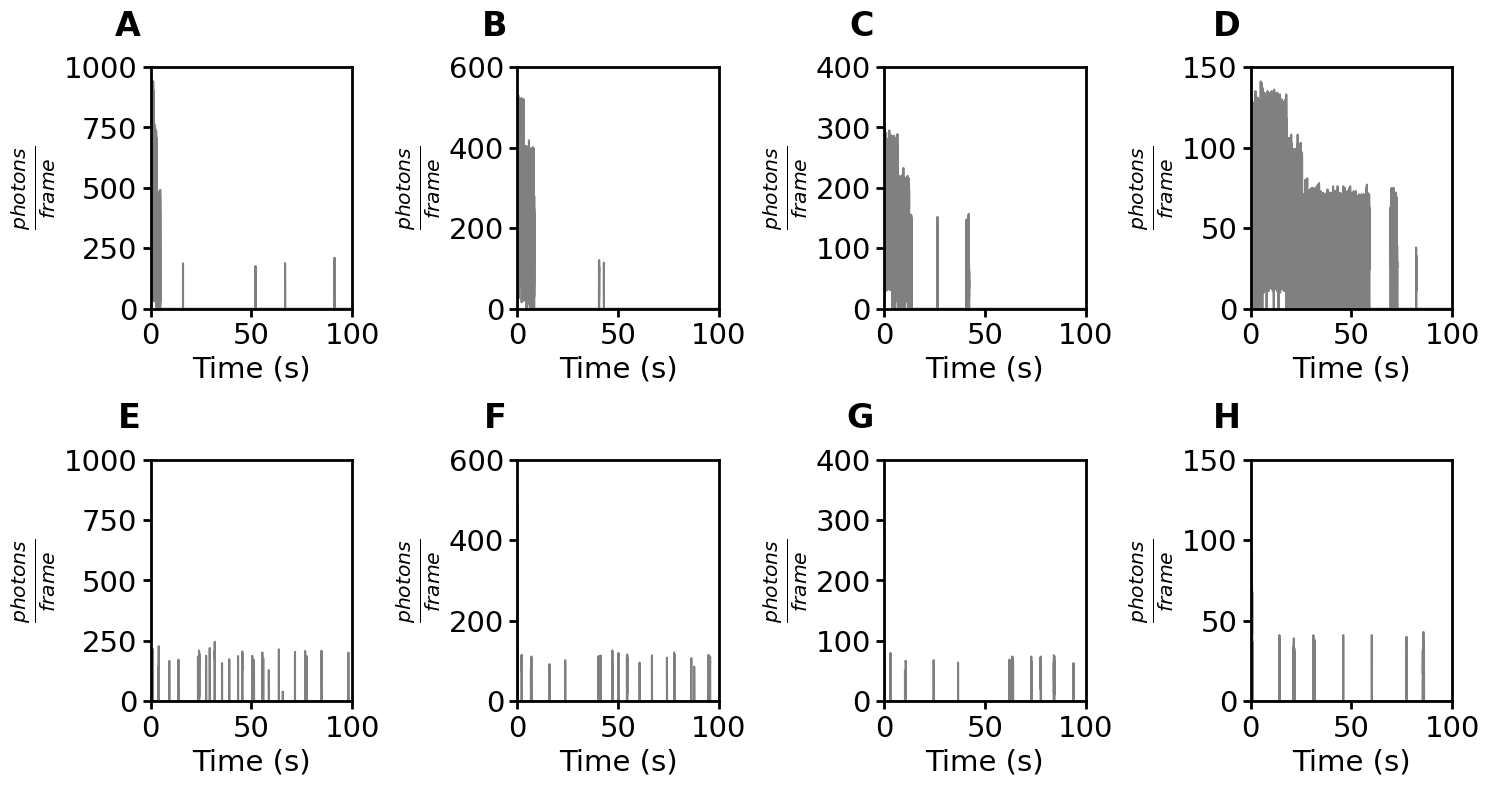

In [5]:
rcParams["axes.linewidth"] = 2
gs = plt.GridSpec(2, 4)
fig = plt.figure(figsize=(15, 8))
emis = em.Emissions()

ax1 = fig.add_subplot(gs[0, 0])
emis.event_time_series = df100_OET.iloc[:, 1]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 1000], axes=ax1, color="grey")
ax3 = fig.add_subplot(gs[0, 1])
emis.event_time_series = df50_OET.iloc[:, 3]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 600], axes=ax3, color="grey")
ax5 = fig.add_subplot(gs[0, 2])
emis.event_time_series = df25_OET.iloc[:, 2]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 400], axes=ax5, color="grey")
ax7 = fig.add_subplot(gs[0, 3])
emis.event_time_series = df10_OET.iloc[:, 2]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 150], axes=ax7, color="grey")

ax2 = fig.add_subplot(gs[1, 0])
emis.event_time_series = df100_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 1000], axes=ax2, color="grey")
ax4 = fig.add_subplot(gs[1, 1])
emis.event_time_series = df50_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 600], axes=ax4, color="grey")
ax6 = fig.add_subplot(gs[1, 2])
emis.event_time_series = df25_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 400], axes=ax6, color="grey")
ax8 = fig.add_subplot(gs[1, 3])
emis.event_time_series = df10_noOET.iloc[:, 0]
emis.plot_time_series(xlim=[0, 100], ylim=[0, 150], axes=ax8, color="grey")

axes = fig.get_axes()
for axis, letter in zip(axes, ["A", "B", "C", "D", "E", "F", "G", "H"]):
    offset = -0.05
    axis.text(
        offset,
        1.1,
        letter,
        transform=axis.transAxes,
        fontsize=24,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

fig.tight_layout()
bbox = mi.compute_tight_bbox(fig, pad_inches=0.1)
fig.savefig(
    saving_to + r"\multi_f_et_irradiance.png",
    dpi=300,
    bbox_inches=bbox,
)